In [1]:
import glob
import os
import sys
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import matplotlib.cm as cm

cmap = cm.inferno

# load data from parquet files
experiment_df = pl.read_parquet('./Results/optimisation_experiments.parquet')
best_policy_df = pl.read_parquet('./Results/optimisation_best_policies.parquet')
outcomes_df = pl.read_parquet('./Results/optimisation_outcomes.parquet')

## KNOWN WEALTH

### Plot Time-Based Optimisation Policy Evolution

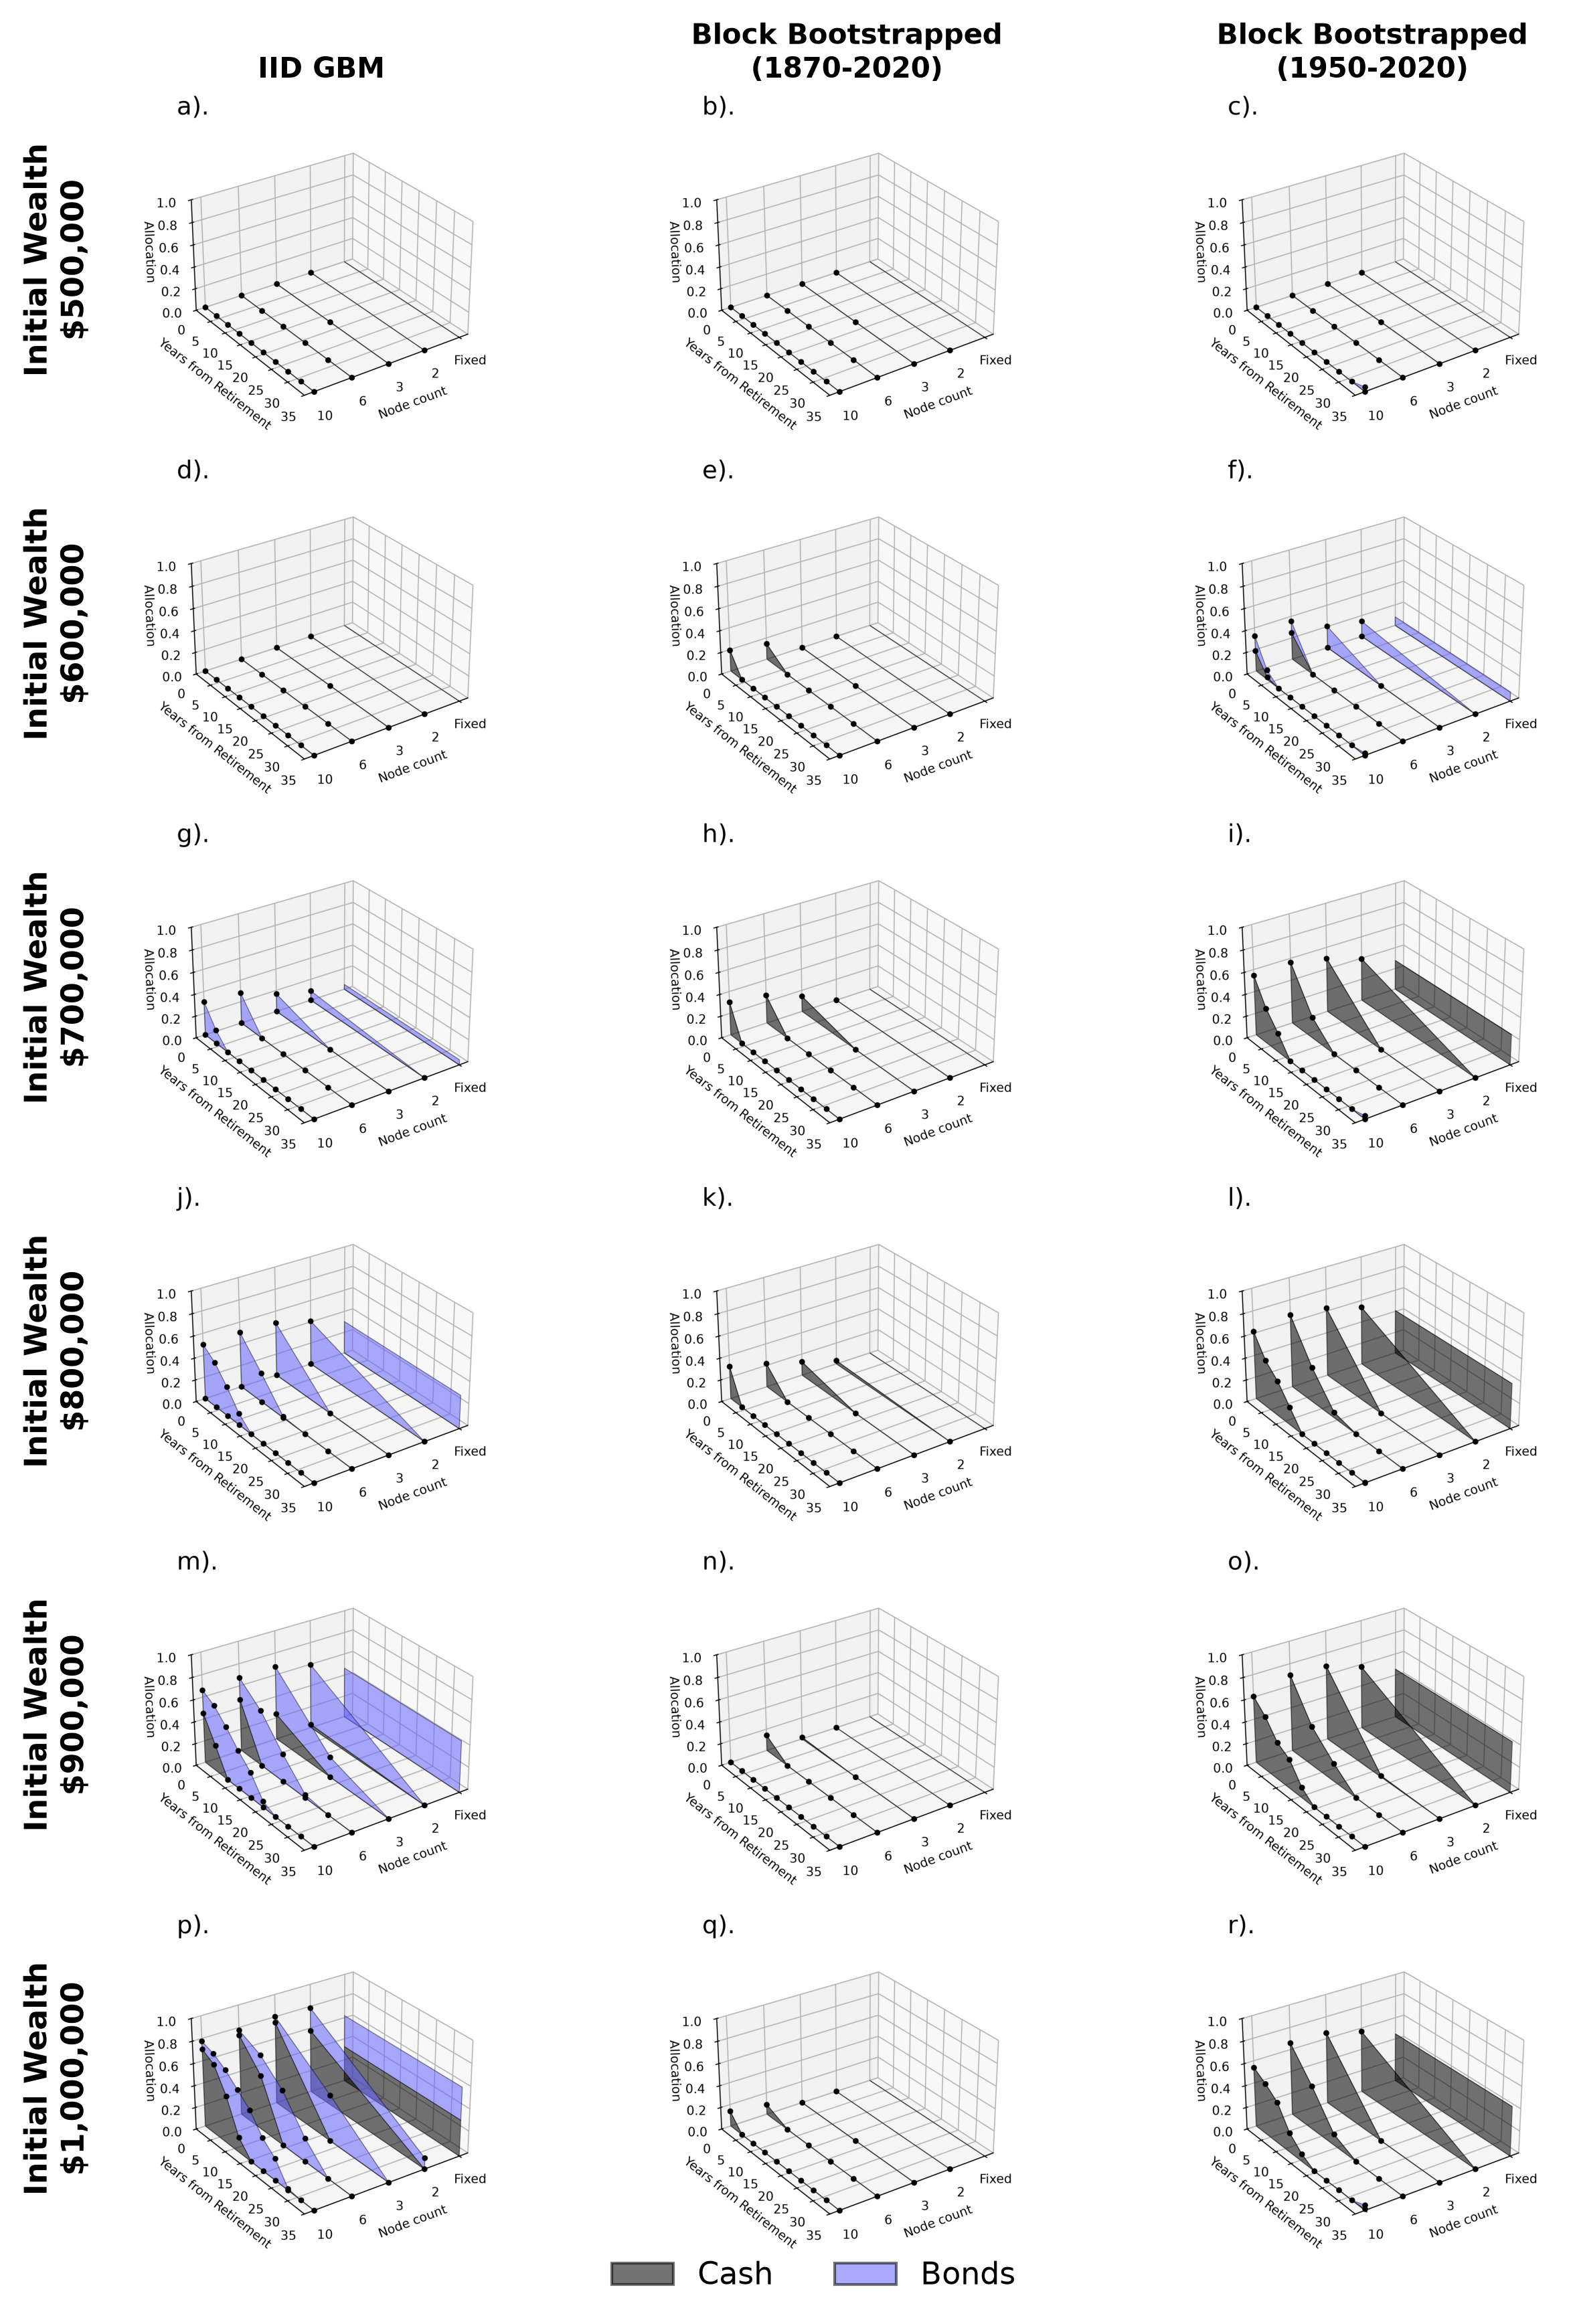

In [2]:
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch


policy_data = best_policy_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    pl.col('n_wealth_nodes') == 1
)

initial_wealths_to_plot = [
    500_000,
    600_000,
    700_000,
    800_000,
    900_000,
    1_000_000,
]

samplers_to_plot = [
    'cholesky',
    'block_bootstrapped',
    'block_bootstrapped_1950'
]

RETURN_SAMPLER_DISPLAY_NAMES = {
    "cholesky": "IID GBM",
    "block_bootstrapped": "Block Bootstrapped\n(1870-2020)",
    "block_bootstrapped_1950": "Block Bootstrapped\n(1950-2020)",
}

colors = {
    'Cash': '#000000',
    'Bonds': '#6464FF',
    'Stocks': '#ff6464',
}

nodes_to_plot = [
    1,
    2,
    3,
    # 4,
    6,
    10,
]

node_positions = {
    1: 0.0,
    2: 0.2,
    3: 0.4,
    6: 0.6,
    10: 0.8,
}



plot_output_dir = os.path.join('Plots', 'TimeBasedPolicy_vs_NodeCount')
os.makedirs(plot_output_dir, exist_ok=True)

saved_files = []
plot_number = 0

for initial_wealth in initial_wealths_to_plot:
    for sampler in samplers_to_plot:
        fig = plt.figure(figsize=(4, 4.8))
        fig.subplots_adjust(left=0.14, right=0.98, bottom=0.06, top=0.88)
        ax = fig.add_subplot(1, 1, 1, projection='3d')
        ax.set_box_aspect((1.1, 1.1, 0.7))

        this_policy_data = policy_data.filter(
            (pl.col('initial_wealth') == initial_wealth)
            & (pl.col('sampler') == sampler)
        ).sort('n_time_nodes', 'time_node')

        cash_polys = []
        stock_polys = []
        bond_polys = []
        node_labels = []
        node_levels = []
        cash_points = []
        bond_points = []
        stock_points = []

        time_min = np.inf
        time_max = -np.inf

        # Create polys for time-based policies
        for n in nodes_to_plot:
            policy_subset = this_policy_data.filter(pl.col('n_time_nodes') == n).sort('time_node')

            if n == 1:
                continue

            if len(policy_subset) == 1:
                x = None
            else:
                x = np.asarray(policy_subset['time_node'].to_list(), dtype=float)
            cash = np.asarray(policy_subset['cash'].to_list(), dtype=float)
            stocks = np.asarray(policy_subset['stocks'].to_list(), dtype=float)
            bonds = np.asarray(policy_subset['bonds'].to_list(), dtype=float)

            cash_lower = np.zeros_like(cash)
            cash_upper = cash
            bond_lower = cash_upper
            bond_upper = bond_lower + bonds
            stock_lower = bond_upper
            stock_upper = bond_upper + stocks

            cash_polys.append(list(zip(x, cash_upper)) + list(zip(x[::-1], cash_lower[::-1])))
            # stock_polys.append(list(zip(x, stock_upper)) + list(zip(x[::-1], stock_lower[::-1])))
            bond_polys.append(list(zip(x, bond_upper)) + list(zip(x[::-1], bond_lower[::-1])))
            node_labels.append(n)
            node_levels.append(node_positions[n])
            cash_points.extend((node_positions[n], t, z) for t, z in zip(x, cash_upper))
            bond_points.extend((node_positions[n], t, z) for t, z in zip(x, bond_upper))
            stock_points.extend((node_positions[n], t, z) for t, z in zip(x, stock_upper))

            time_min = min(time_min, float(x.min()))    
            time_max = max(time_max, float(x.max()))

        # create the fixed policy subset for plotting
        fixed_policy_subset = this_policy_data.filter(pl.col('n_time_nodes') == 1).sort('time_node')
        x = np.array([time_min, time_max])
        cash = fixed_policy_subset['cash'].first()
        stocks = fixed_policy_subset['stocks'].first()
        bonds = fixed_policy_subset['bonds'].first()

        cash_lower = np.zeros(2)
        cash_upper = np.full(2, cash)
        bond_lower = cash_upper
        bond_upper = bond_lower + bonds
        stock_lower = bond_upper
        stock_upper = bond_upper + stocks

        cash_polys.append(list(zip(x, cash_upper)) + list(zip(x[::-1], cash_lower[::-1])))
        bond_polys.append(list(zip(x, bond_upper)) + list(zip(x[::-1], bond_lower[::-1])))
        node_labels.append('Fixed')
        node_levels.append(node_positions[1])


        if this_policy_data.height == 0:
            ax.text2D(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center')
            ax.set_axis_off()
        elif not node_levels:
            ax.text2D(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center', va='center')
            ax.set_axis_off()
        else:
            for verts, color in [
                (cash_polys, colors['Cash']),
                (bond_polys, colors['Bonds']),
                # (stock_polys, colors['Stocks']),
            ]:
                poly = PolyCollection(
                    verts,
                    facecolors=color,
                    edgecolors='black',
                    linewidths=0.6,
                    alpha=0.55,
                )
                ax.add_collection3d(poly, zs=node_levels, zdir='x')

            # Add scatter points for the time-based policies
            for points, color in [
                (cash_points, colors['Cash']),
                (bond_points, colors['Bonds']),
                # (stock_points, colors['Stocks']),
            ]:
                if points and len(points) > 1:
                    point_array = np.asarray(points, dtype=float)
                    ax.scatter(
                        point_array[:, 0],
                        point_array[:, 1],
                        point_array[:, 2],
                        color='k',
                        edgecolors='black',
                        linewidths=0.4,
                        s=18,
                        depthshade=False,
                    )
            tick_pairs = sorted(zip(node_levels, node_labels), key=lambda p: p[0])
            xtick_positions = [p[0] for p in tick_pairs]
            xtick_labels = ['Fixed' if p[1] == 'Fixed' else str(p[1]) for p in tick_pairs]
            ax.set_xlim(min(node_levels) - 0.05, max(node_levels) + 0.05)
            ax.set_ylim(time_min, time_max)
            ax.set_zlim(0, 1)
            ax.set_xlabel('Node count', labelpad=4)
            ax.set_xticks(xtick_positions)
            ax.set_xticklabels(xtick_labels)
            ax.set_ylabel('Years from Retirement', labelpad=4)
            ax.set_zlabel('Allocation', labelpad=0)
            ax.view_init(elev=28, azim=55)

            legend_handles = [
                Patch(facecolor=color, edgecolor='black', alpha=0.55, label=label)
                for label, color in colors.items()
            ]
            # ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(colors))
            ax.set_title(
                f"{chr(97 + plot_number)}).", loc='left', size=20
            )
            plot_number += 1

        output_name = f"{sampler}_wealth_{int(initial_wealth):,}.png".replace(',', '')
        output_path = os.path.join(plot_output_dir, output_name)
        fig.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.2)
        saved_files.append(output_path)
        plt.close(fig)

n_rows = len(initial_wealths_to_plot)
n_cols = len(samplers_to_plot)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8.27, 11.69),  # A4 portrait in inches
    dpi=300,
    squeeze=False,
    constrained_layout=False,
 )

for i, initial_wealth in enumerate(initial_wealths_to_plot):
    for j, sampler in enumerate(samplers_to_plot):
        ax: plt.Axes = axes[i, j]
        filename = f"{sampler}_wealth_{int(initial_wealth)}.png"
        image_path = os.path.join(plot_output_dir, filename)

        if os.path.exists(image_path):
            image = plt.imread(image_path)
            ax.imshow(image)
        else:
            ax.text(0.5, 0.5, 'Missing image', ha='center', va='center', fontsize=9)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

for j, sampler in enumerate(samplers_to_plot):
    axes[0, j].set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=10, fontweight='bold', pad=8, y=0.94)

for i, initial_wealth in enumerate(initial_wealths_to_plot):
    axes[i, 0].set_ylabel(
        f"Initial Wealth\n${initial_wealth:,.0f}",
        fontsize=11,
        fontweight='bold',
        rotation=90,
        labelpad=16,
    )

legend_handles = [
    Patch(facecolor=color, edgecolor='black', alpha=0.55, label=label)
    for label, color in colors.items() if label in ['Cash', 'Bonds']
 ]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.015),
    ncol=len(legend_handles),
    frameon=False,
    fontsize=11,
 )

fig.subplots_adjust(
    left=0.05,
    right=0.99,
    top=0.97,
    bottom=0.04,
    wspace=0.03,
    hspace=0.00,
 )

a4_output_png = './Plots/Time_Based_Policy_Evolution.png'

fig.savefig(a4_output_png, dpi=400)
# fig.savefig(a4_output_pdf)
plt.show()

### Plot Bankruptcy Density of Time-Based Optimisation Policy Evolution

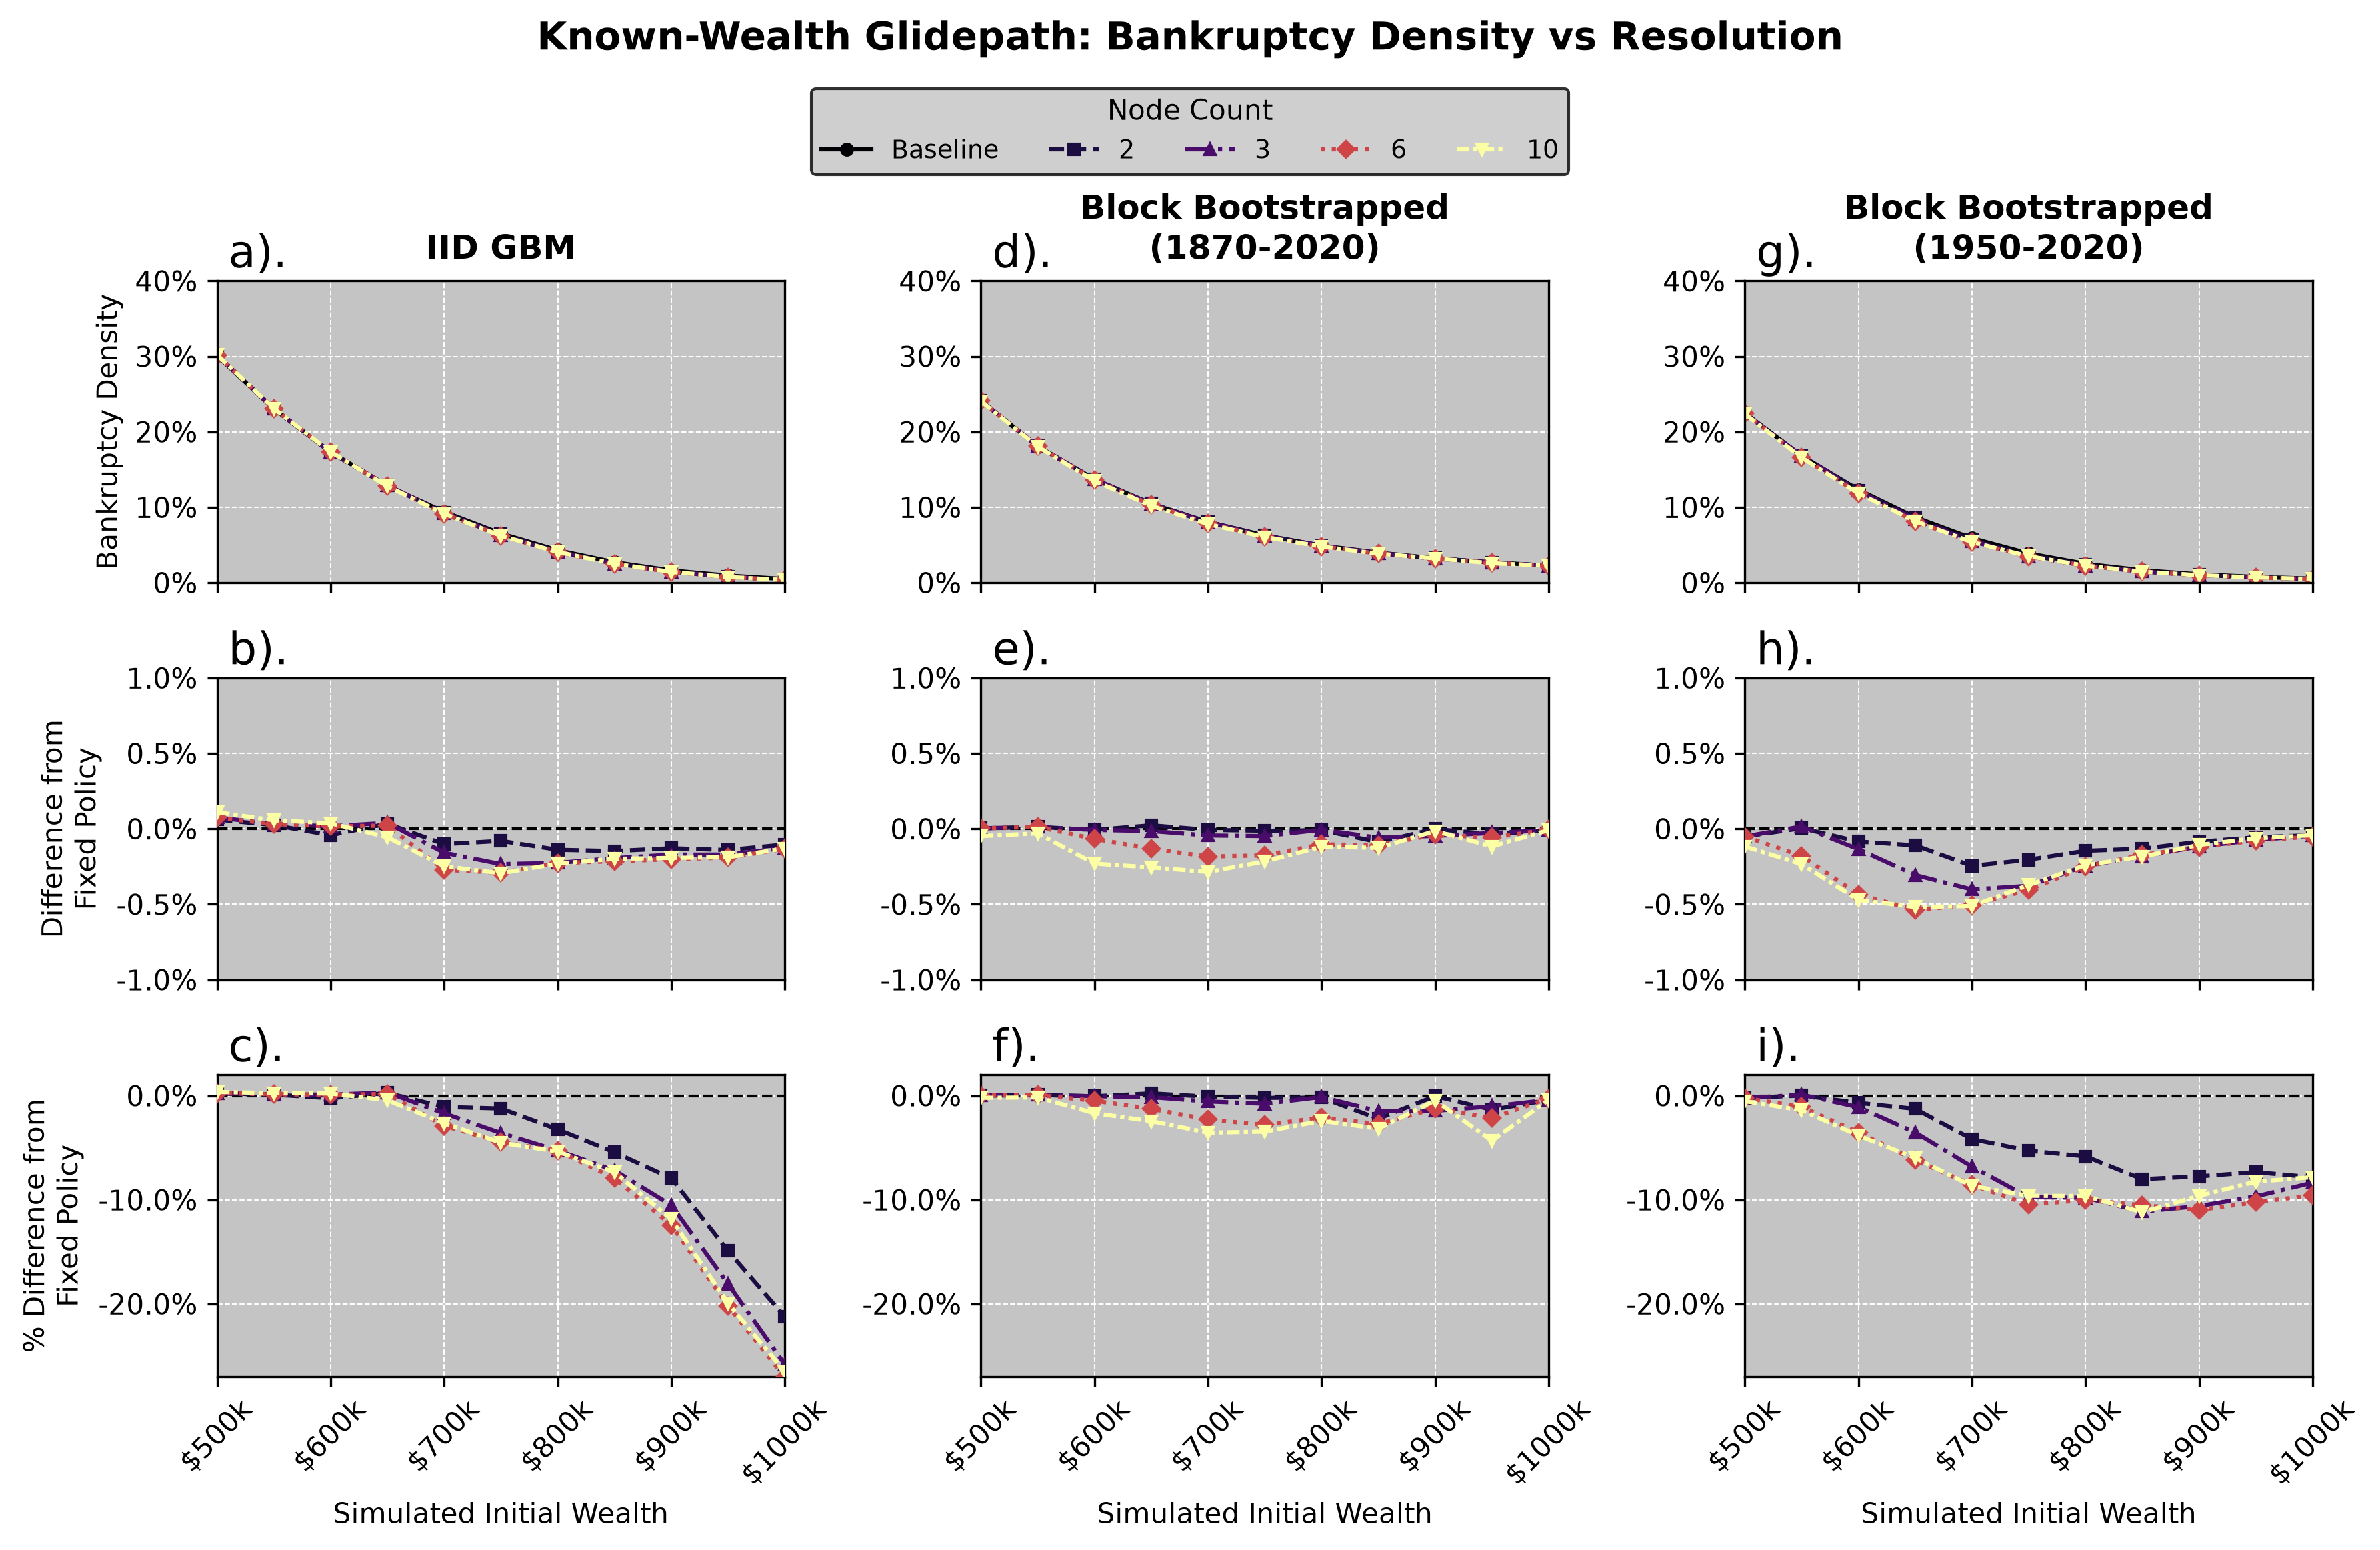

In [3]:
from plot_utils import plot_metric_vs_node_baseline

# Prepare outcome data: time-based policy with known/single initial wealth
outcome_data = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == 1)
    & (pl.col('initial_wealth').is_not_null())
)

# Plot bankruptcy density vs time node counts
fig, axes = plot_metric_vs_node_baseline(
    outcome_data=outcome_data,
    nodes_to_plot=[1, 2, 3, 6, 10],
    samplers_to_plot=samplers_to_plot,
    node_dimension='time',  # Vary n_time_nodes
    metric='bankruptcy_density',
    baseline_node_count=1,
    metric_label='Bankruptcy Density',
    diff_label='Difference from\nFixed Policy',
    rel_diff_label='% Difference from\nFixed Policy',
    top_ylim=(0, 0.4),
    diff_ylim=(-0.01, 0.01),
    rel_diff_ylim=(-0.27, 0.02),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
)

plt.suptitle('Known-Wealth Glidepath: Bankruptcy Density vs Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Bankruptcy_Density_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

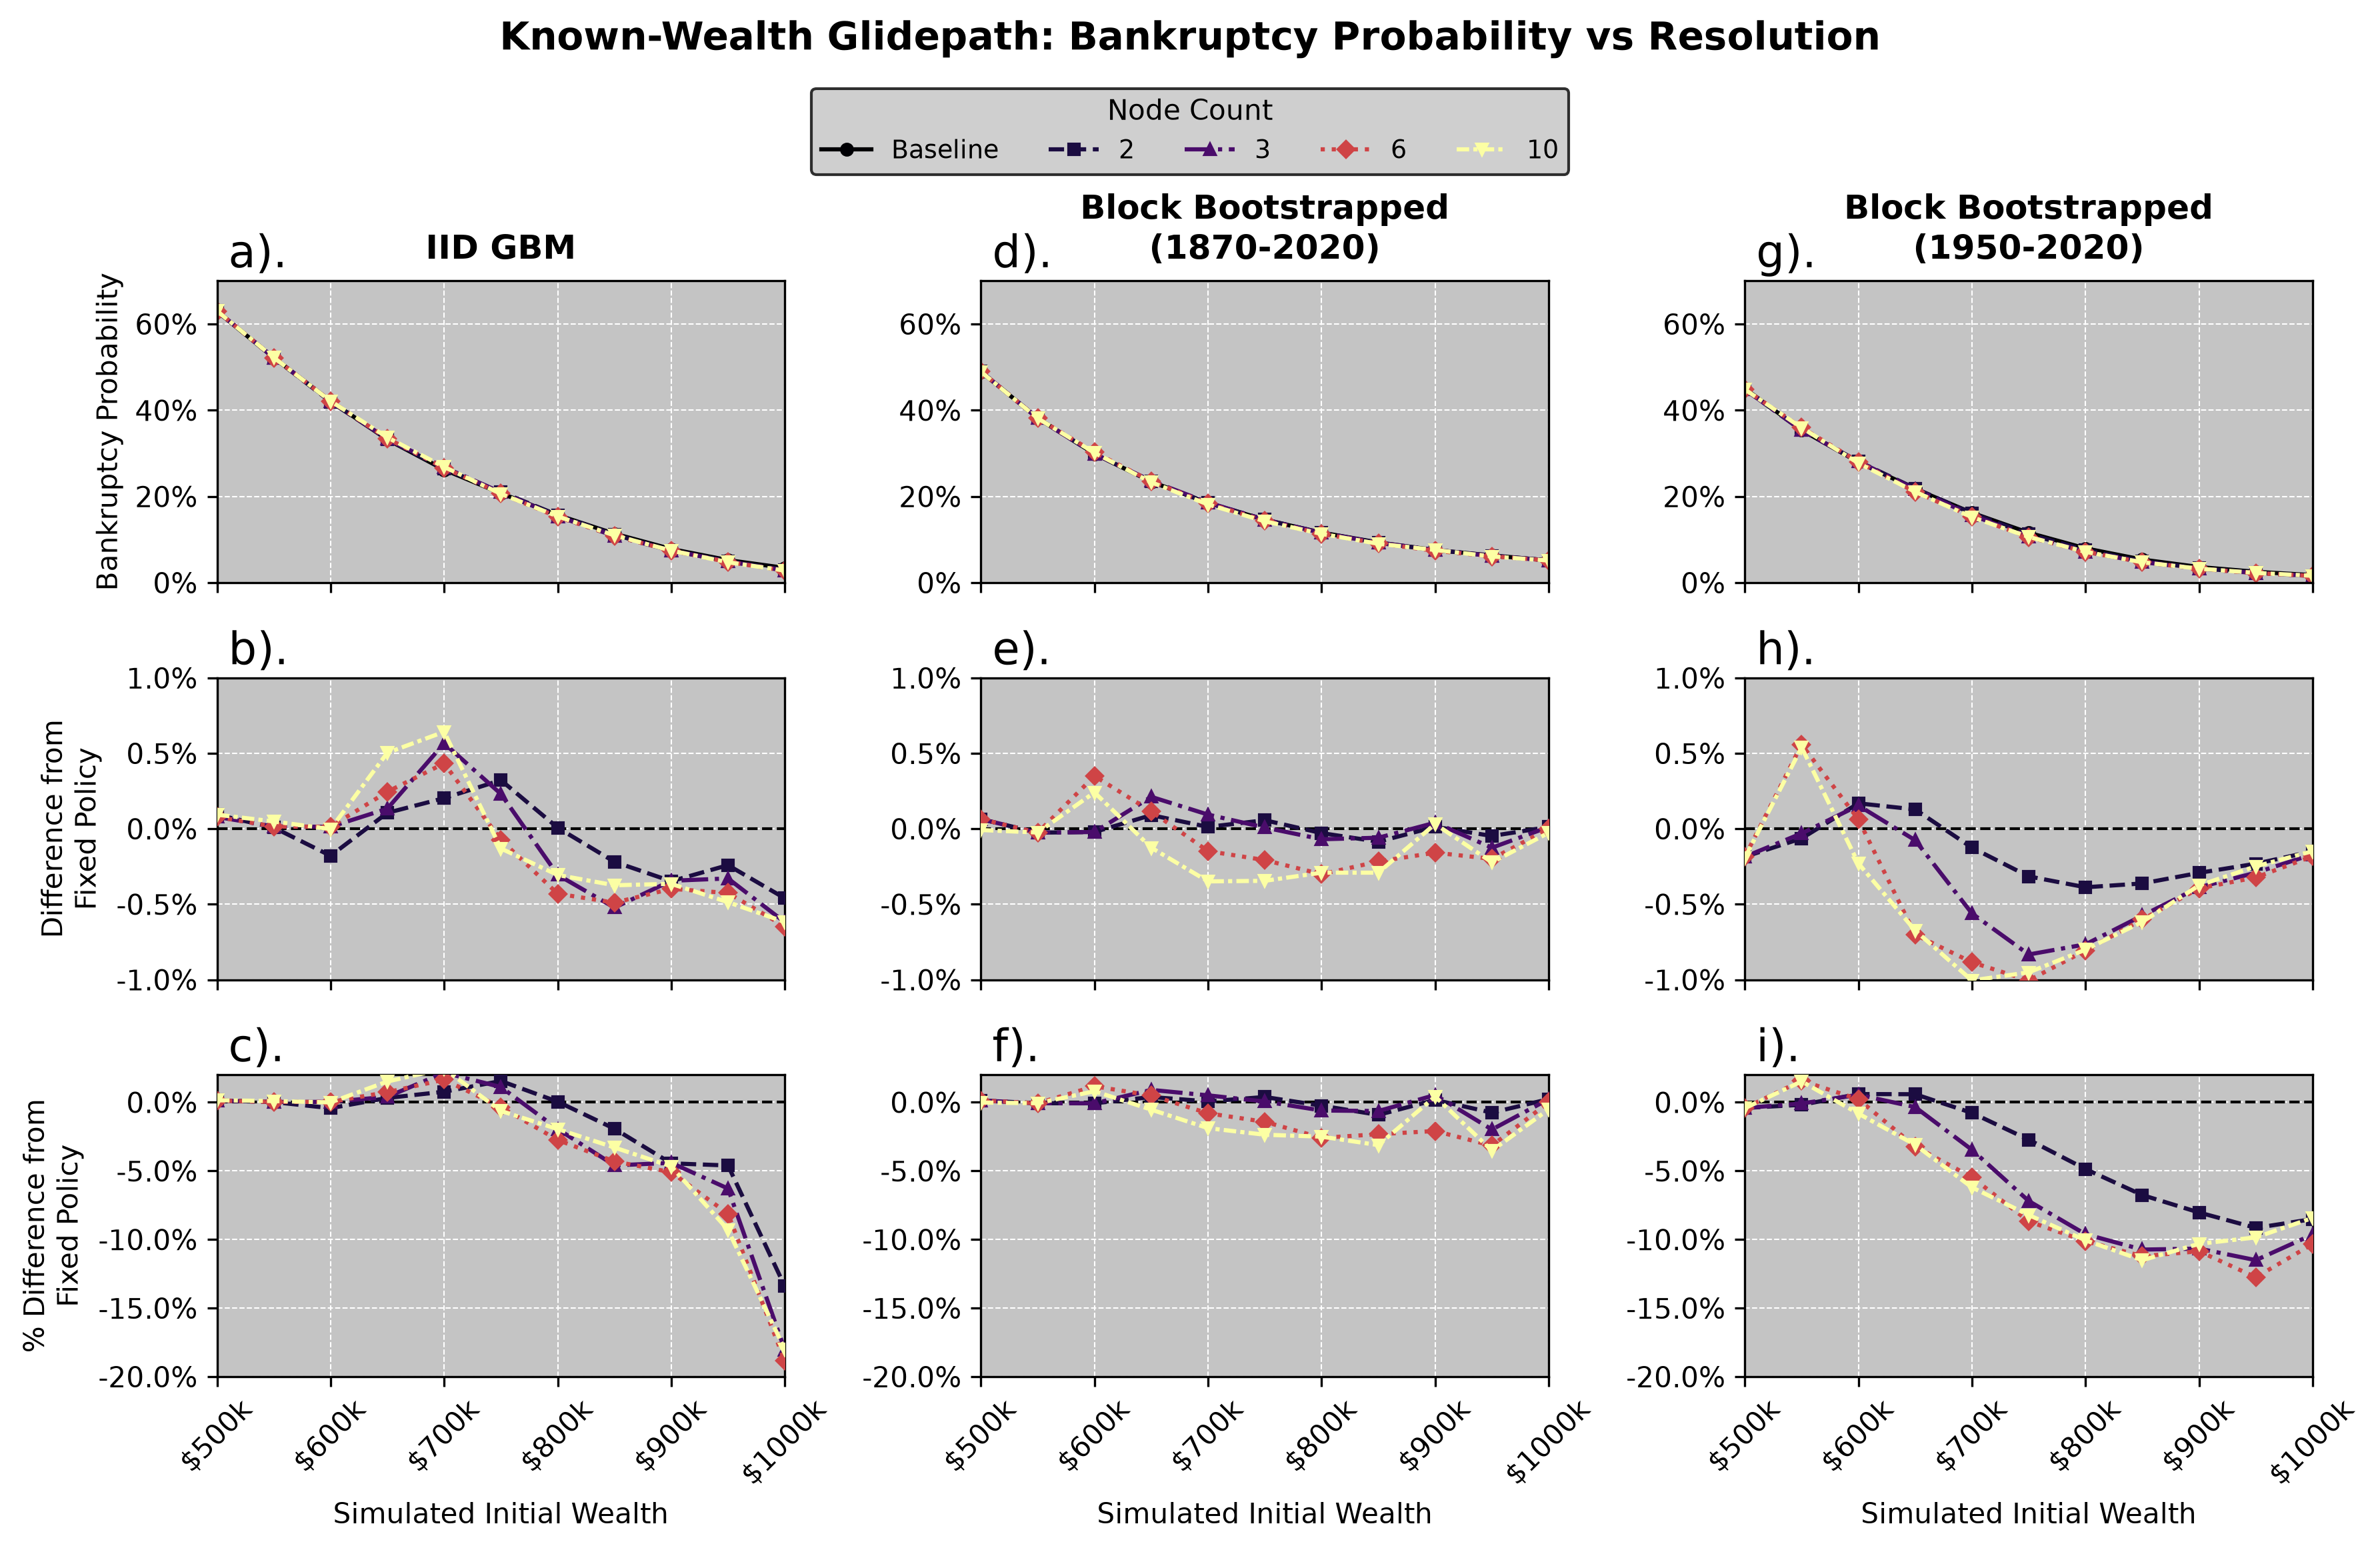

In [4]:
fig, axes = plot_metric_vs_node_baseline(
    outcome_data=outcome_data,
    nodes_to_plot=[1, 2, 3, 6, 10],
    samplers_to_plot=samplers_to_plot,
    node_dimension='time',  # Vary n_time_nodes
    metric='bankruptcy_probability',
    baseline_node_count=1,
    metric_label='Bankruptcy Probability',
    diff_label='Difference from\nFixed Policy',
    rel_diff_label='% Difference from\nFixed Policy',
    top_ylim=(0, 0.7),
    diff_ylim=(-0.01, 0.01),
    rel_diff_ylim=(-0.2, 0.02),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
)

plt.suptitle('Known-Wealth Glidepath: Bankruptcy Probability vs Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Bankruptcy_Probability_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

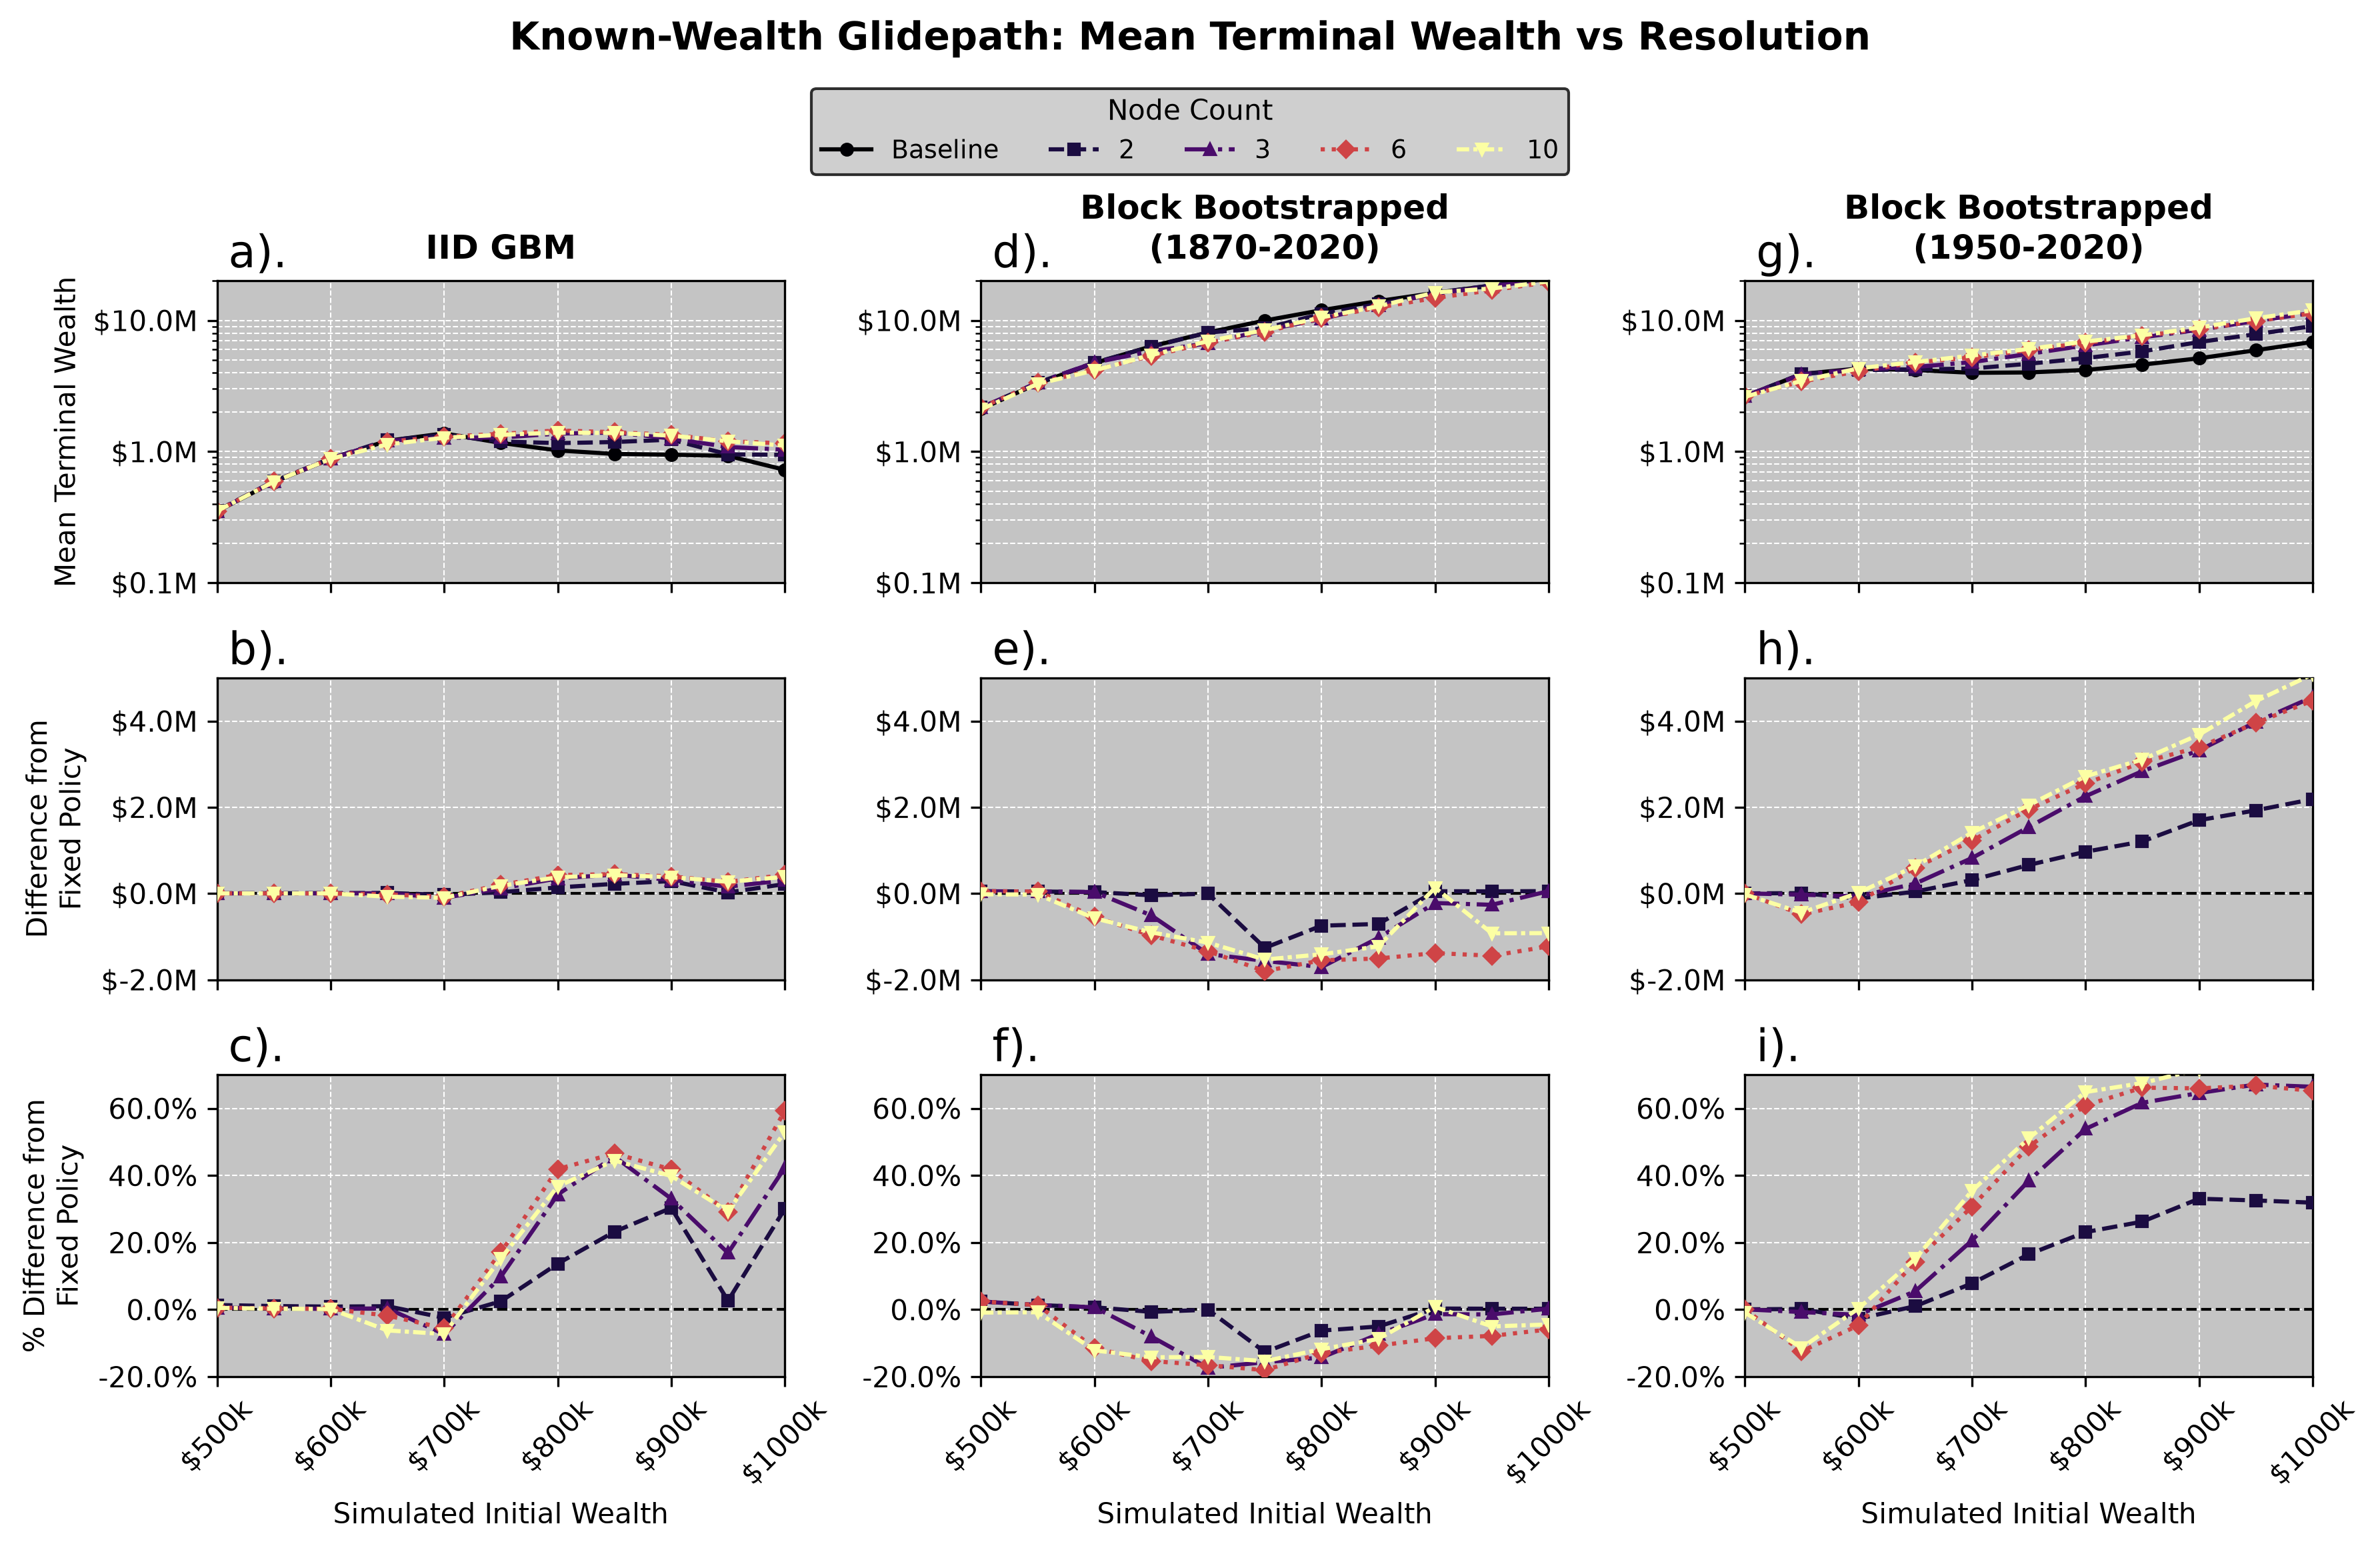

In [5]:
fig, axes = plot_metric_vs_node_baseline(
    outcome_data=outcome_data,
    nodes_to_plot=[1, 2, 3, 6, 10],
    samplers_to_plot=samplers_to_plot,
    node_dimension='time',  # Vary n_time_nodes
    metric='mean_terminal_wealth',
    baseline_node_count=1,
    metric_label='Mean Terminal Wealth',
    diff_label='Difference from\nFixed Policy',
    rel_diff_label='% Difference from\nFixed Policy',
    top_ylim=(1e5, 2e7),
    diff_ylim=(-2e6, 5e6),
    rel_diff_ylim=(-0.2, 0.7),
    top_as_percent=False,
    diff_as_percent=False,
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
)

for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')

currency_fmt = plt.FuncFormatter(lambda y, _: f'${y/1_000_000:.1f}M' if np.isfinite(y) else '')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)

plt.suptitle('Known-Wealth Glidepath: Mean Terminal Wealth vs Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Mean_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

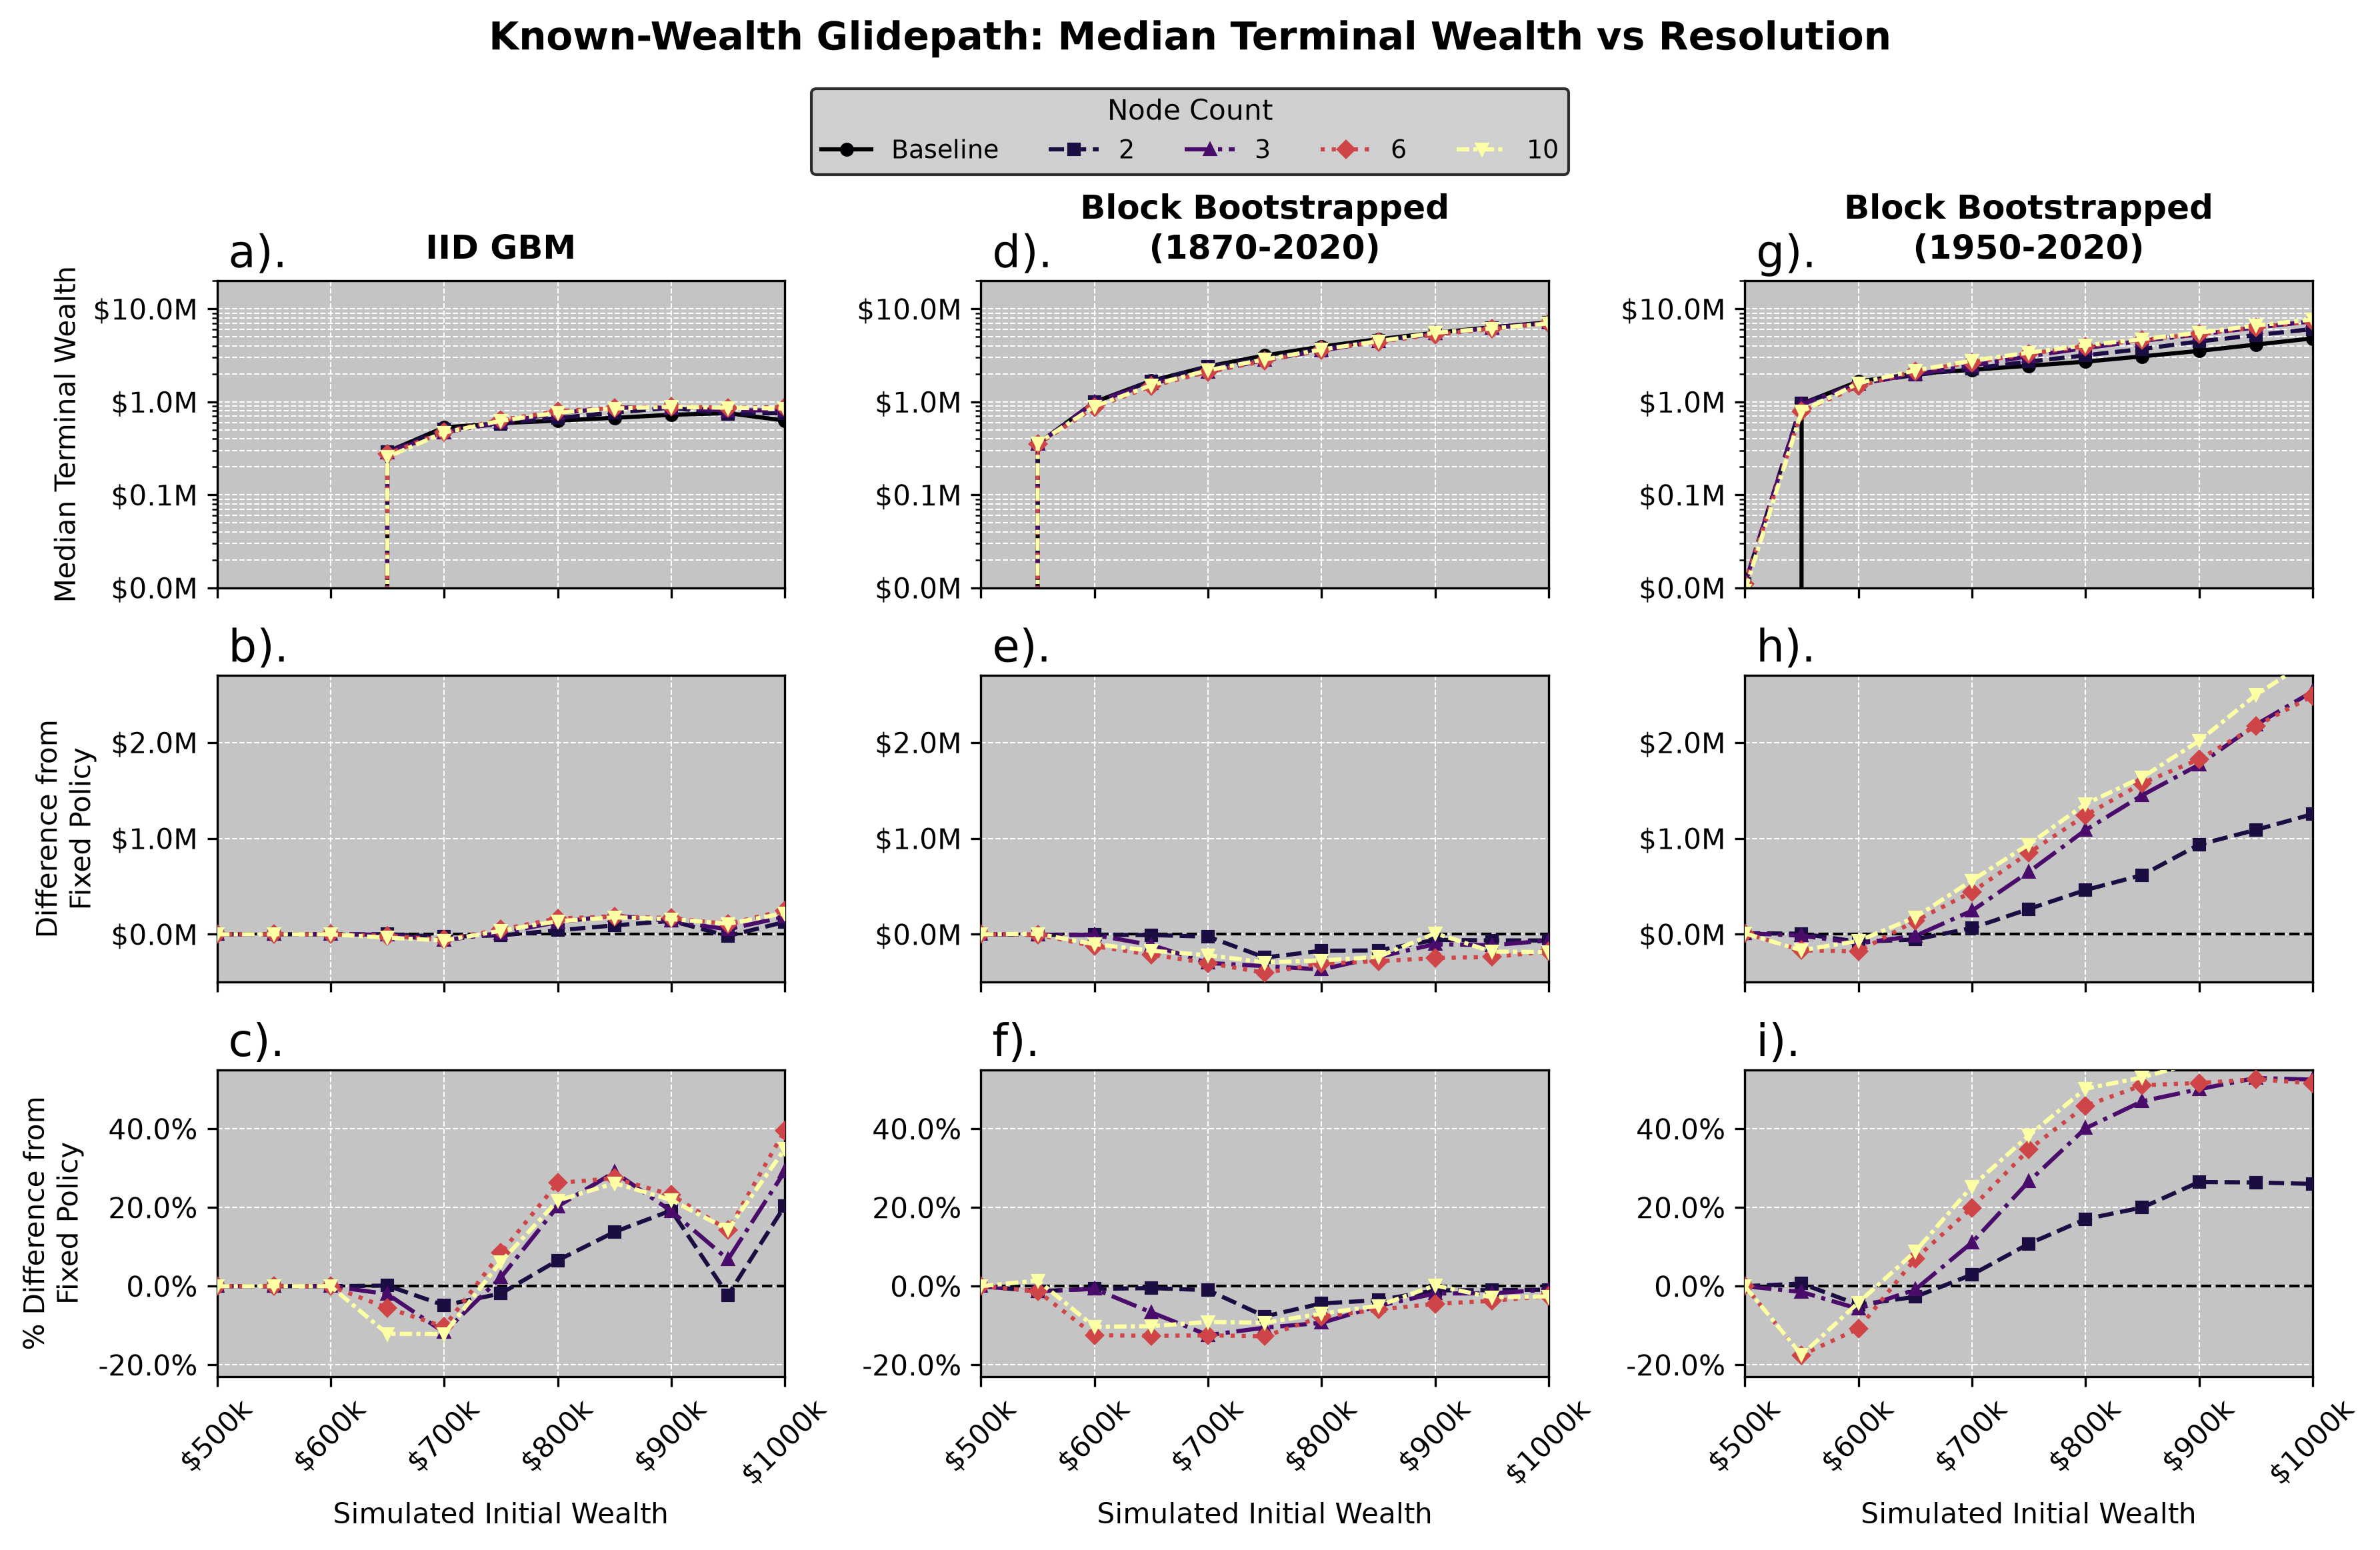

In [6]:
fig, axes = plot_metric_vs_node_baseline(
    outcome_data=outcome_data.with_columns(pl.col('median_terminal_wealth').cast(pl.Int64)),
    nodes_to_plot=[1, 2, 3, 6, 10],
    samplers_to_plot=samplers_to_plot,
    node_dimension='time',  # Vary n_time_nodes
    metric='median_terminal_wealth',
    baseline_node_count=1,
    metric_label='Median Terminal Wealth',
    diff_label='Difference from\nFixed Policy',
    rel_diff_label='% Difference from\nFixed Policy',
    top_ylim=(1e4, 2e7),
    diff_ylim=(-5e5, 2.7e6),
    rel_diff_ylim=(-0.23, 0.55),
    top_as_percent=False,
    diff_as_percent=False,
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
)

for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')

currency_fmt = plt.FuncFormatter(lambda y, _: f'${y/1_000_000:.1f}M' if np.isfinite(y) else '')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)

plt.suptitle('Known-Wealth Glidepath: Median Terminal Wealth vs Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Time_Based_Policy_Median_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

## DISTRIBUTED WEALTH

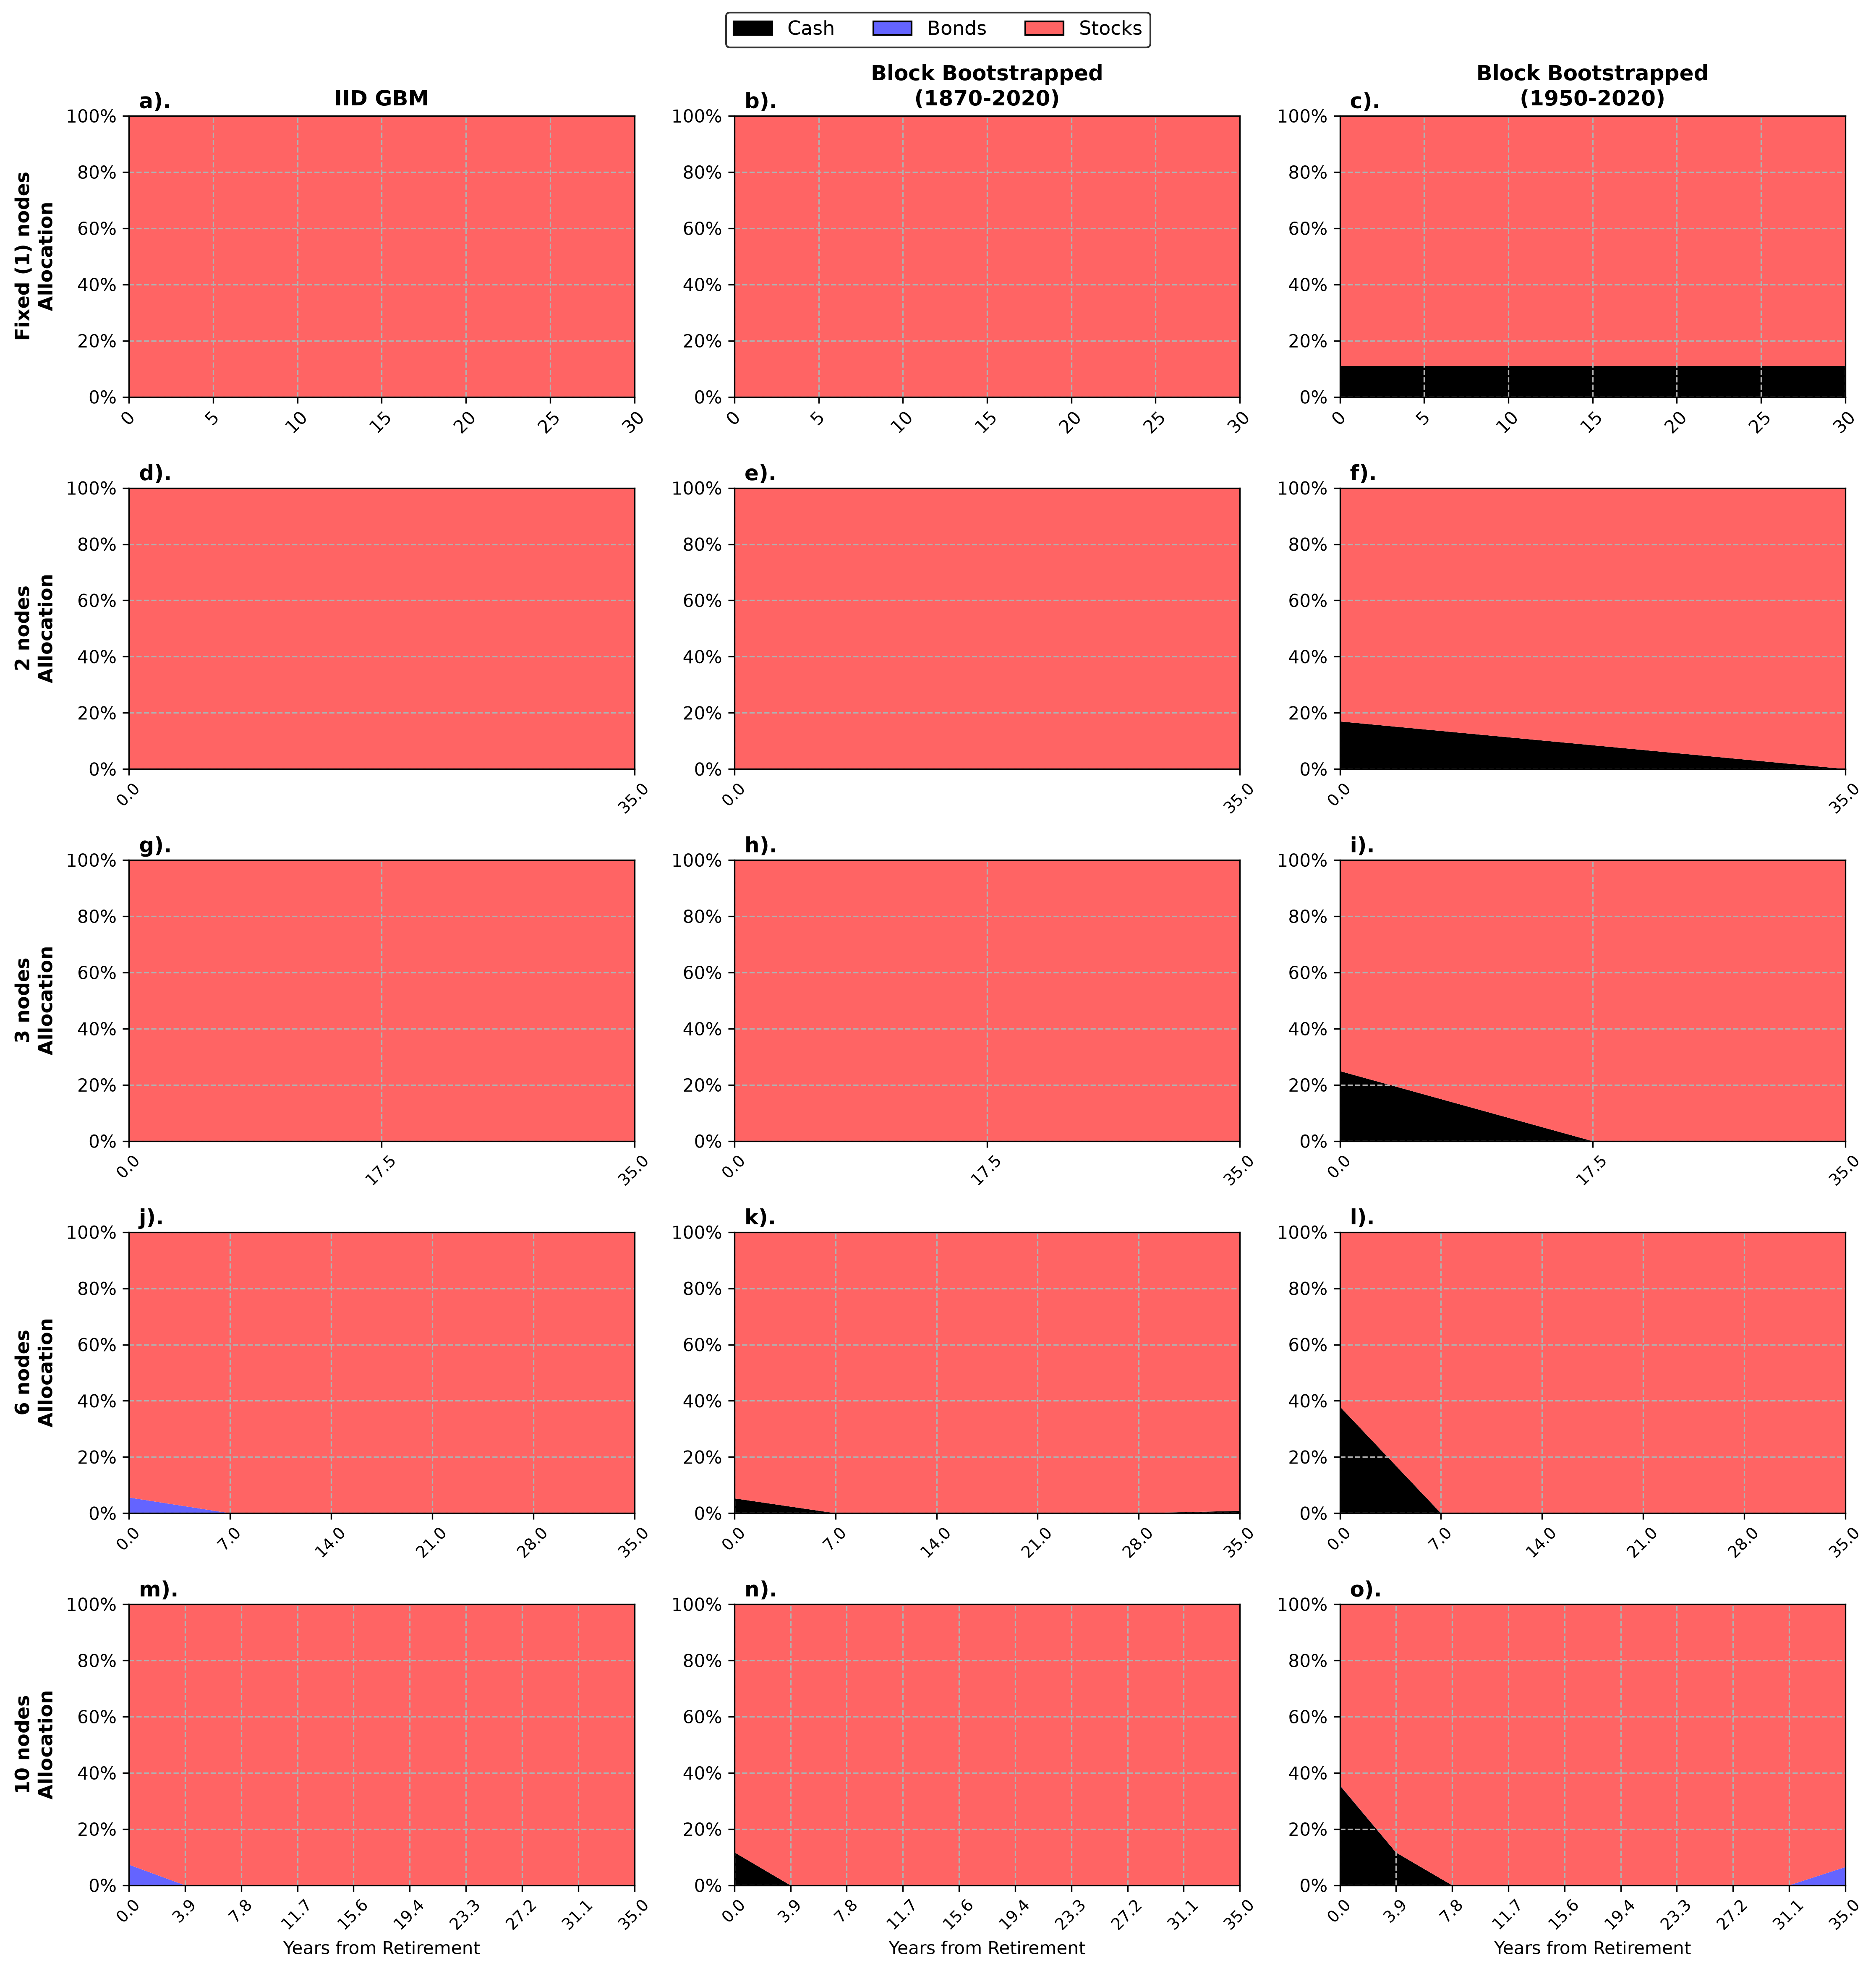

In [7]:
# 2D stackplot: Evolution of glidepath policy with increasing time node counts
# Each row shows one node count, columns show different samplers

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

percent_formatter = plt.FuncFormatter(lambda y, _: f'{y:.0%}')

TIME_NODE_COUNTS_TO_PLOT = [1, 2, 3, 6, 10]
TIME_PLOT_MIN = 0
TIME_PLOT_MAX = 30
TIME_SURFACE_X = np.linspace(TIME_PLOT_MIN, TIME_PLOT_MAX, 300)

NODE_PLOT_LABELS = {1: 'Fixed (1)', 2: '2', 3: '3', 4: '4', 6: '6', 8: '8', 10: '10'}

policy_2d_data = best_policy_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == 1)
    & (pl.col('n_time_nodes').is_in(TIME_NODE_COUNTS_TO_PLOT))
    & (pl.col('initial_wealth').is_null())
)

fig, axes = plt.subplots(
    len(TIME_NODE_COUNTS_TO_PLOT),
    len(samplers_to_plot),
    figsize=(15, 16),
    dpi=300,
)

for row_idx, node_count in enumerate(TIME_NODE_COUNTS_TO_PLOT):
    for col_idx, sampler in enumerate(samplers_to_plot):
        ax = axes[row_idx, col_idx]
        
        this_policy = policy_2d_data.filter(pl.col('sampler') == sampler)
        
        node_policy = this_policy.filter(
            (pl.col('n_time_nodes') == node_count)
        ).sort('time_node')
        
        if node_policy.height == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        
        if node_count == 1:
            x_min, x_max = TIME_PLOT_MIN, TIME_PLOT_MAX
            surface_x = np.linspace(x_min, x_max, 300)
            cash_vals = np.full_like(surface_x, float(node_policy['cash'][0]), dtype=float)
            bond_vals = np.full_like(surface_x, float(node_policy['bonds'][0]), dtype=float)
            stock_vals = np.full_like(surface_x, float(node_policy['stocks'][0]), dtype=float)
            node_x = []
            node_cash = []
            node_bond = []
            node_stock = []
        else:
            source_time = np.array(node_policy['time_node'].to_list(), dtype=float)
            x_min, x_max = float(source_time.min()), float(source_time.max())
            surface_x = np.linspace(x_min, x_max, 300)
            cash_vals = np.interp(surface_x, source_time, np.array(node_policy['cash'].to_list(), dtype=float))
            bond_vals = np.interp(surface_x, source_time, np.array(node_policy['bonds'].to_list(), dtype=float))
            stock_vals = np.interp(surface_x, source_time, np.array(node_policy['stocks'].to_list(), dtype=float))
            node_x = source_time
            node_cash = np.array(node_policy['cash'].to_list(), dtype=float)
            node_bond = np.array(node_policy['bonds'].to_list(), dtype=float)
            node_stock = np.array(node_policy['stocks'].to_list(), dtype=float)
        
        # Stackplot with face colors
        ax.stackplot(
            surface_x,
            cash_vals,
            bond_vals,
            stock_vals,
            labels=['Cash', 'Bonds', 'Stocks'],
            colors=[colors['Cash'], colors['Bonds'], colors['Stocks']],
        )
        
        # Overlay scatter points at the actual nodes
        # if len(node_x) > 0:
        #     node_total = node_cash + node_bond + node_stock
        #     ax.scatter(node_x, node_cash, color='k', s=50, marker='o', zorder=5)
        #     bond_y = node_cash + node_bond
        #     ax.scatter(node_x, bond_y, color='k', s=50, marker='o', zorder=5)
        #     ax.scatter(node_x, node_total, color='k', s=50, marker='o', linewidths=1.5, zorder=5)
        
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, 1)

        # X-ticks at actual node positions, falling back to uniform spacing for fixed policy
        if len(node_x) > 0:
            ax.set_xticks(node_x)
            ax.set_xticklabels([f'{t:.1f}' for t in node_x], fontsize=9)
        else:
            ax.set_xticks(np.arange(x_min, x_max + 1, 5))

        ax.tick_params(axis='x', rotation=45)
        ax.set_yticks(np.arange(0, 1.2, 0.2))
        ax.yaxis.set_major_formatter(percent_formatter)
        ax.grid(linestyle='--', alpha=1)
        
        # Column titles (sampler names)
        if row_idx == 0:
            ax.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=12, fontweight='bold')
        
        # Row labels (node counts)
        if col_idx == 0:
            ax.set_ylabel(f'{NODE_PLOT_LABELS[node_count]} nodes\nAllocation', fontsize=11, fontweight='bold')
        
        # X-axis label only on bottom row
        if row_idx == len(TIME_NODE_COUNTS_TO_PLOT) - 1:
            ax.set_xlabel('Years from Retirement', fontsize=10)
        else:
            ax.set_xlabel('')
        
        ax.text(0.02, 1.01, chr(97 + row_idx * len(samplers_to_plot) + col_idx) + ').',
                transform=ax.transAxes, fontsize=12, va='bottom', ha='left', fontweight='bold')

# Create shared legend above all plots
legend_elements = [
    Patch(facecolor=colors['Cash'], edgecolor='black', label='Cash'),
    Patch(facecolor=colors['Bonds'], edgecolor='black', label='Bonds'),
    Patch(facecolor=colors['Stocks'], edgecolor='black', label='Stocks'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=8, label='Node'),
]
fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=4,
    fontsize=11,
    frameon=True,
    edgecolor='black',
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('./Plots/Time_Based_Policy_2D_Node_vs_Time_Distributed_Init_Wealth.png', dpi=400, bbox_inches='tight', pad_inches=0.2)
plt.show()


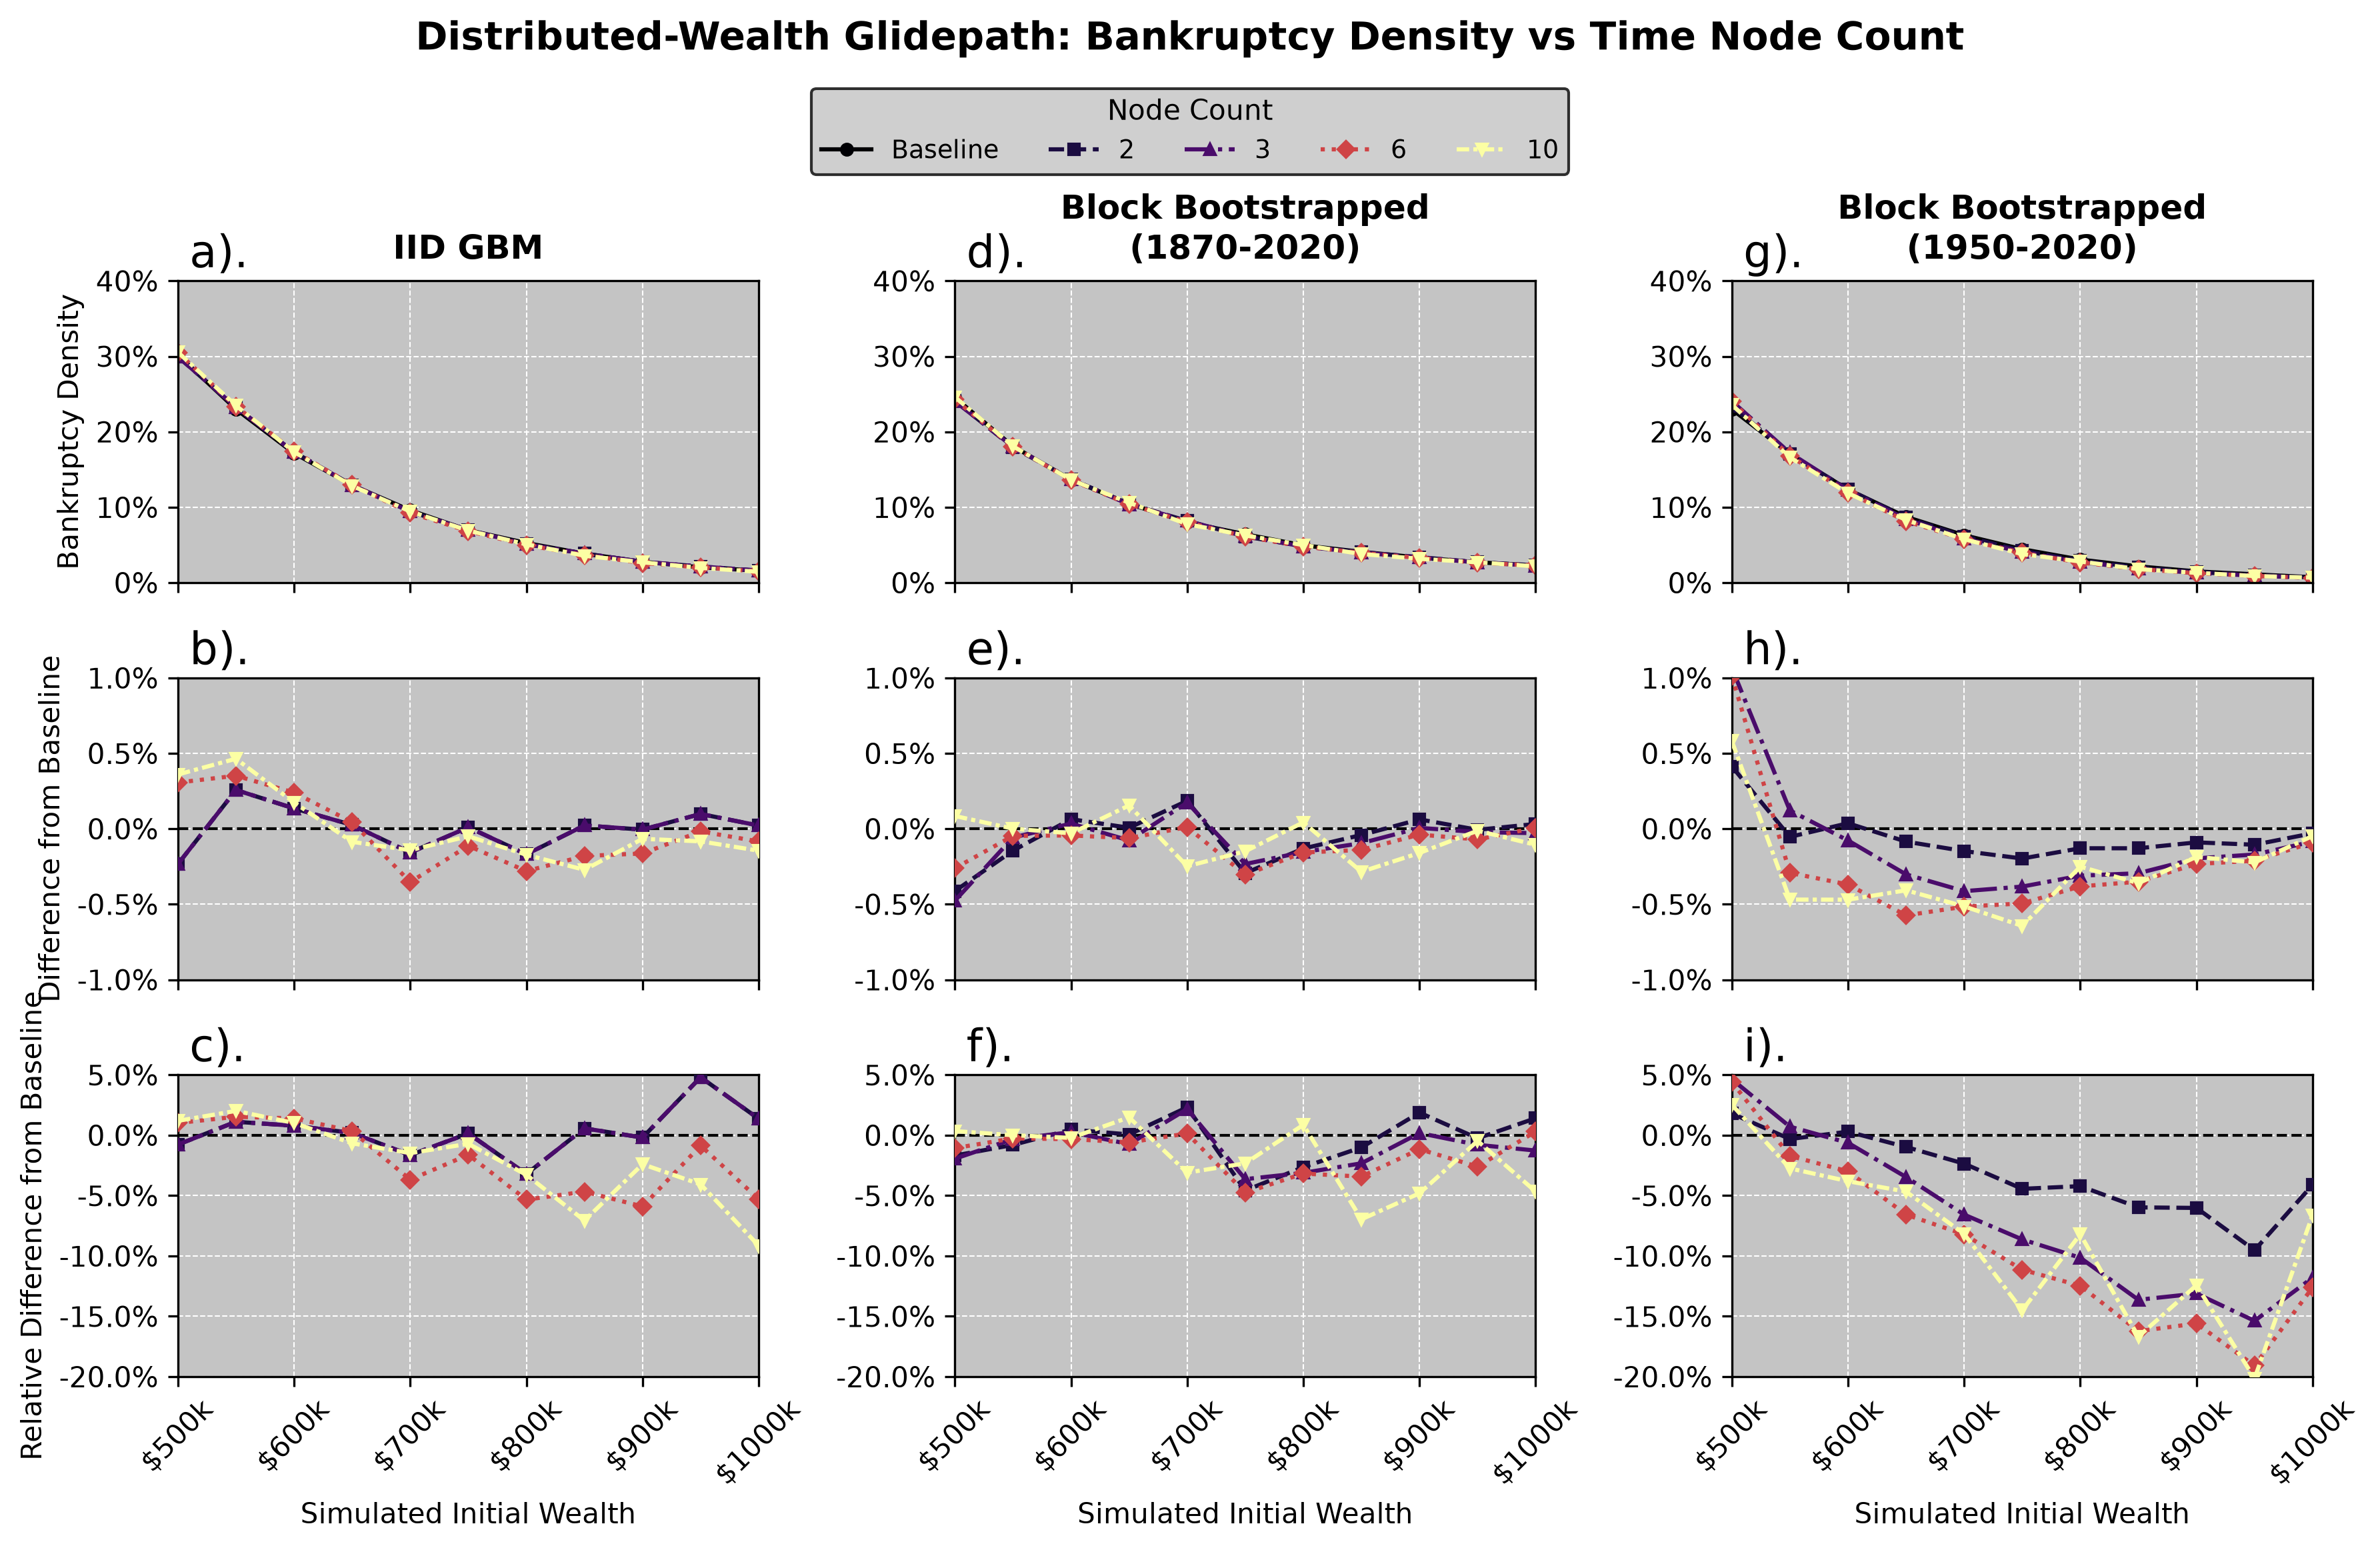

In [8]:
# Example: Using generalized plot_metric_vs_node_baseline for time-based policies
# This demonstrates plotting glidepath outcomes with different time node resolutions

# Glidepath outcomes: time-based policy with distributed initial wealth
time_nodes_to_plot = [1, 2, 3, 6, 10]
outcome_time_nodes = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == 1)
    & (pl.col('n_time_nodes').is_in(time_nodes_to_plot))
    & (pl.col('initial_wealth').is_null())
)

# Plot bankruptcy density vs time node counts
fig, axes = plot_metric_vs_node_baseline(
    outcome_data=outcome_time_nodes,
    nodes_to_plot=time_nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    node_dimension='time',  # Vary n_time_nodes
    metric='bankruptcy_density',
    baseline_node_count=1,
    metric_label='Bankruptcy Density',
    sampler_display_names=RETURN_SAMPLER_DISPLAY_NAMES,
    diff_ylim=(-0.01, 0.01),
    rel_diff_ylim=(-0.2, 0.05),
    top_ylim=(0, 0.4),
)
plt.suptitle('Distributed-Wealth Glidepath: Bankruptcy Density vs Time Node Count', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Glidepath_Bankruptcy_Density_vs_Time_Nodes_Distributed_Init_Wealth.png', dpi=400, bbox_inches='tight', pad_inches=0.2)
plt.show()